In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [ ]:
df=pd.read_csv('/content/Sale_analysis_project_DATASET.csv')
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [ ]:
df.drop(['Status','unnamed1'],axis=1,inplace=True)

In [ ]:
df.isnull().sum()

,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
pd.isnull(df).sum()

,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


In [ ]:
df['Amount'].dtypes

dtype('float64')

In [ ]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [ ]:
df.rename(columns={'Marital_Status':'Shaadi'},inplace=True)

In [ ]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Shaadi', 'State', 'Zone', 'Occupation', 'Product_Category', 'Orders',
       'Amount'],
      dtype='object')

In [ ]:
df.describe()

,User_ID,Age,Shaadi,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610858
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355869
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [ ]:
df[['Age','Orders']].describe()

,Age,Orders
count,11239.000000,11239.000000
mean,35.410357,2.489634
std,12.753866,1.114967
min,12.000000,1.000000
25%,27.000000,2.000000
50%,33.000000,2.000000
75%,43.000000,3.000000
max,92.000000,4.000000


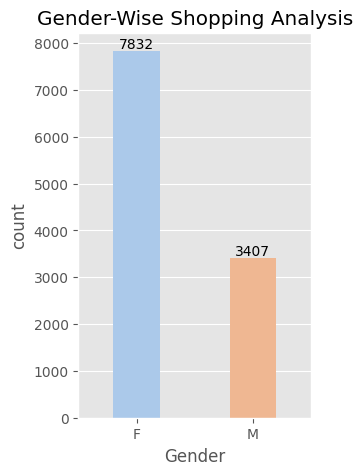

In [ ]:
plt.figure(figsize=(3,5))
gr=sns.countplot(x='Gender',data=df,hue='Gender',width=0.4,palette='pastel')
for bars in gr.containers:
  gr.bar_label(bars)

plt.title('Gender-Wise Shopping Analysis')
plt.show()

In [ ]:
df.groupby('Gender',as_index=False)['Amount'].sum()

,Gender,Amount
0,F,74335856.43
1,M,31913276.00


In [ ]:
df.groupby('Gender')['Amount'].sum()

,Amount
Gender,
F,74335856.43
M,31913276.00


In [ ]:
df.groupby('Gender',as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

,Gender,Amount
0,F,74335856.43
1,M,31913276.00


In [ ]:
sales_gen=df.groupby('Gender',as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
print(sales_gen)

  Gender       Amount
0      F  74335856.43
1      M  31913276.00


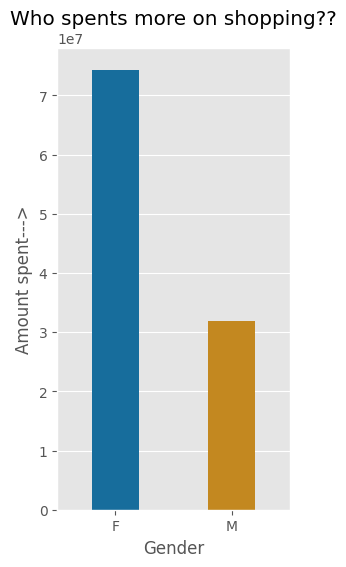

In [ ]:
plt.figure(figsize=(3,6))
sns.barplot(x='Gender',y='Amount',data=sales_gen,hue='Gender',palette='colorblind',width=0.4)
plt.title("Who spents more on shopping??")
plt.ylabel('Amount spent--->')
plt.show()

Text(0.5, 1.0, 'Order Distribution Across Age Groups')

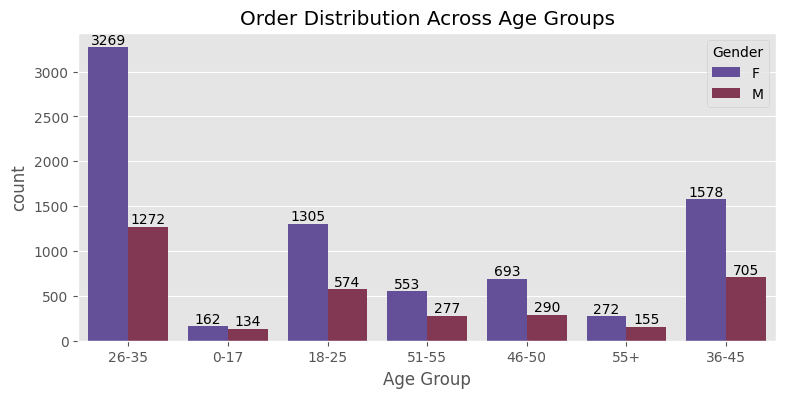

In [ ]:
#SHOPPING TRENDS BY AGE

plt.figure(figsize=(9,4))
gr1=sns.countplot(x='Age Group',hue='Gender',palette='twilight',data=df)
for bars in gr1.containers:
  gr1.bar_label(bars)

plt.title('Order Distribution Across Age Groups')

In [ ]:
sales_age=df.groupby('Age Group',as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
print(sales_age)

  Age Group       Amount
2     26-35  42613443.94
3     36-45  22144995.49
1     18-25  17240732.00
4     46-50   9207844.00
5     51-55   8261477.00
6       55+   4080987.00
0      0-17   2699653.00


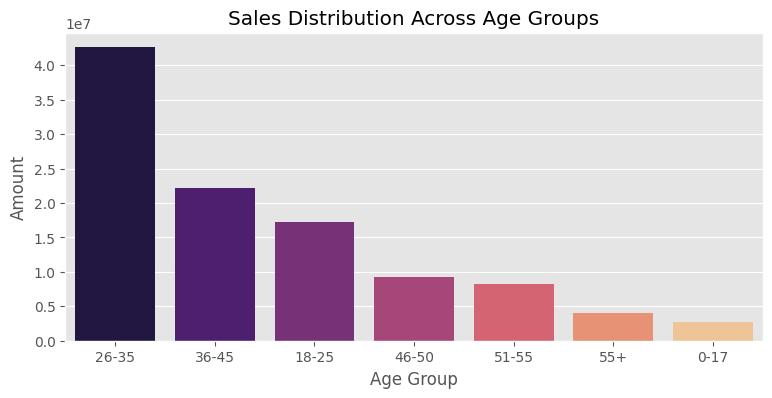

In [ ]:
plt.figure(figsize=(9,4))
sns.barplot(x='Age Group',y='Amount',data=sales_age,hue='Age Group',palette='magma')
plt.title("Sales Distribution Across Age Groups")
plt.show()

In [ ]:
sales_state=df.groupby("State",as_index=False)["Orders"].sum().sort_values(by="Orders",ascending=False)
print(sales_state)

               State  Orders
14     Uttar Pradesh    4807
10       Maharashtra    3810
7          Karnataka    3240
2              Delhi    2740
9     Madhya Pradesh    2252
0     Andhra Pradesh    2051
5   Himachal Pradesh    1568
8             Kerala    1137
4            Haryana    1109
3            Gujarat    1066
1              Bihar    1062
6          Jharkhand     953
15       Uttarakhand     824
12         Rajasthan     555
11            Punjab     495
13         Telangana     312


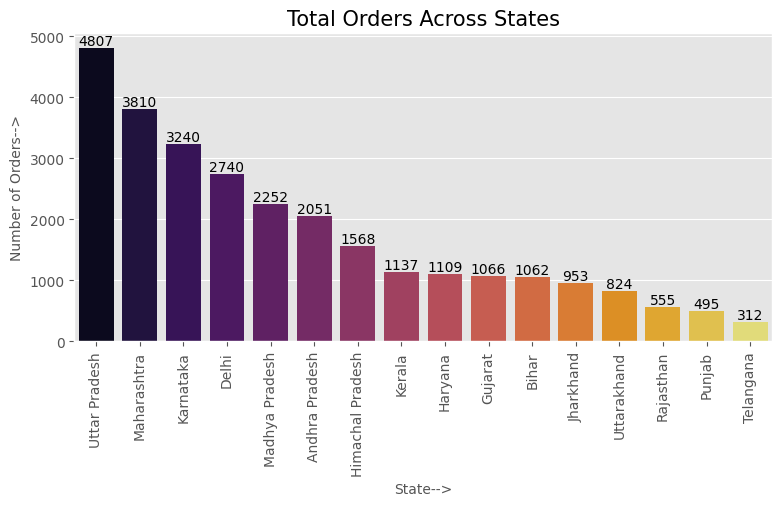

In [ ]:
plt.figure(figsize=(9,4))
gr1=sns.barplot(x="State",y="Orders",data=sales_state,hue="State",palette="inferno")
for bars in gr1.containers:
    gr1.bar_label(bars)
plt.title("Total Orders Across States",size=15)
plt.xlabel("State-->",size=10)
plt.ylabel("Number of Orders-->",size=10)
plt.xticks(size=10,rotation=90)
plt.yticks(size=10)
plt.show()

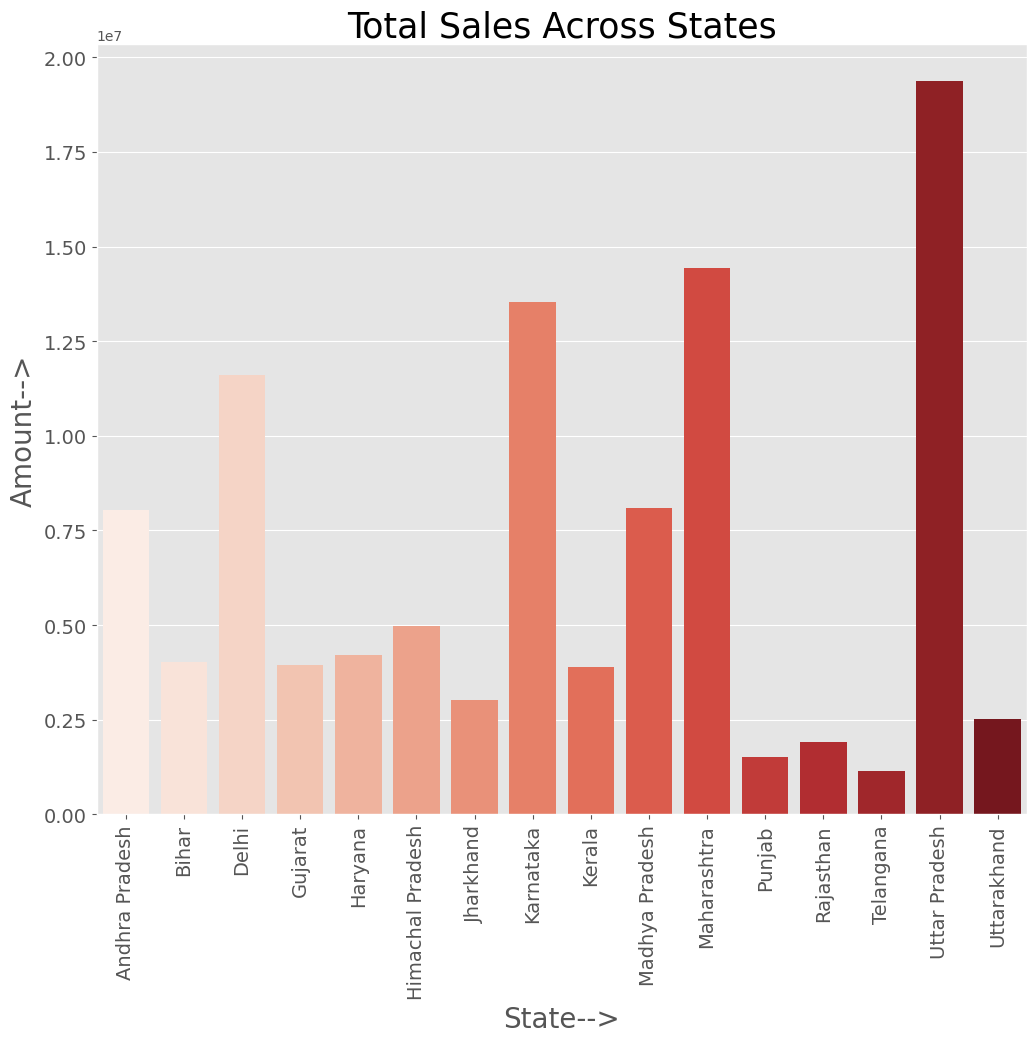

In [ ]:
plt.figure(figsize=(12,10))
sales_state1=df.groupby("State",as_index=False)["Amount"].sum()
gr4=sns.barplot(x="State",y="Amount",data=sales_state1,hue="State",palette="Reds")
plt.title("Total Sales Across States",size=25)
plt.xlabel("State-->",size=20)
plt.ylabel("Amount-->",size=20)
plt.xticks(size=14,rotation=90)
plt.yticks(size=14)
plt.show()

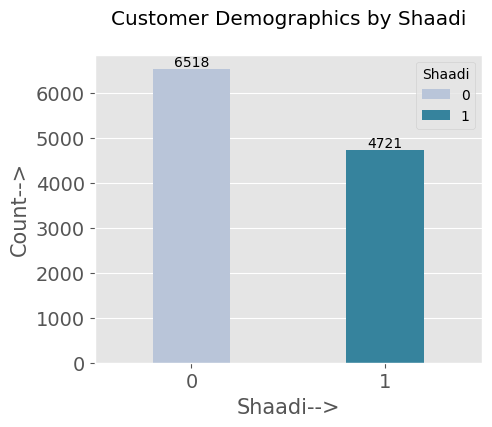

In [ ]:
plt.figure(figsize=(5,4))
ax=sns.countplot(data=df,x="Shaadi",width=0.4,hue="Shaadi",palette="PuBuGn")
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Customer Demographics by Shaadi\n")
plt.xlabel("Shaadi-->",size=15)
plt.ylabel("Count-->",size=15)
plt.xticks(size=14)
plt.yticks(size=14)
plt.show()

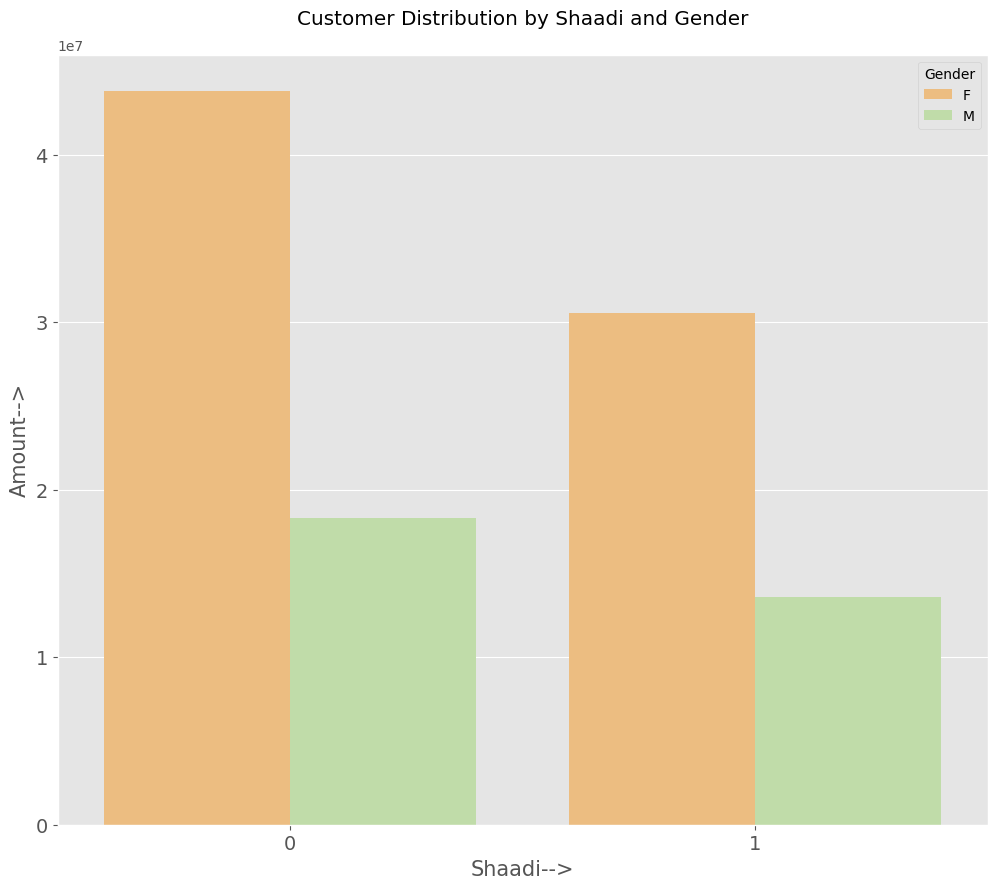

In [ ]:
plt.figure(figsize=(12,10))
Sales_genmar=df.groupby(["Gender","Shaadi"],as_index=False)["Amount"].sum().sort_values(by="Amount",ascending=False)
gr4=sns.barplot(x="Shaadi",y="Amount",hue="Gender",data=Sales_genmar,palette="Spectral")
plt.title("Customer Distribution by Shaadi and Gender\n")
plt.xlabel("Shaadi-->",size=15)
plt.ylabel("Amount-->",size=15)
plt.xticks(size=14)
plt.yticks(size=14)
plt.show()

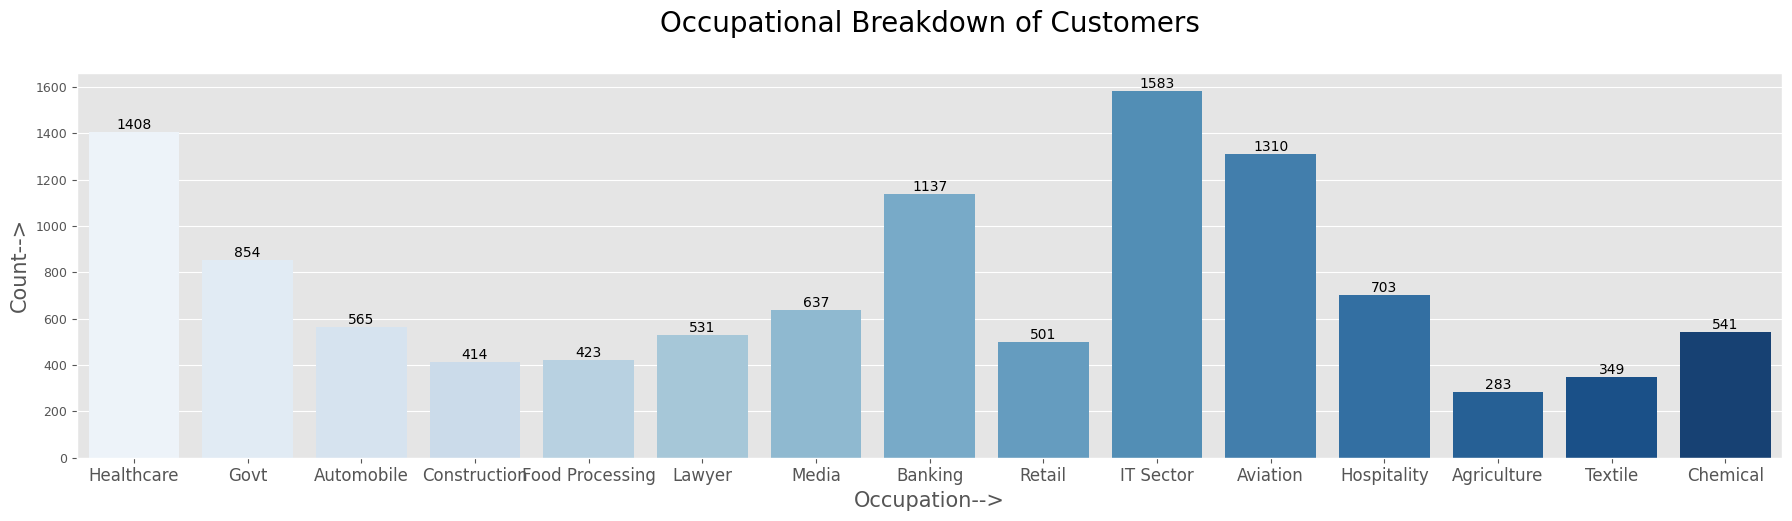

In [ ]:
plt.figure(figsize=(22,5)) #Shoping Trends By OCCUPATION
ax=sns.countplot(data=df,x="Occupation",hue="Occupation",palette="Blues")
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Occupational Breakdown of Customers\n",size=20)
plt.xlabel("Occupation-->",size=15)
plt.ylabel("Count-->",size=15)
plt.xticks(size=12)
plt.yticks(size=9)
plt.show()

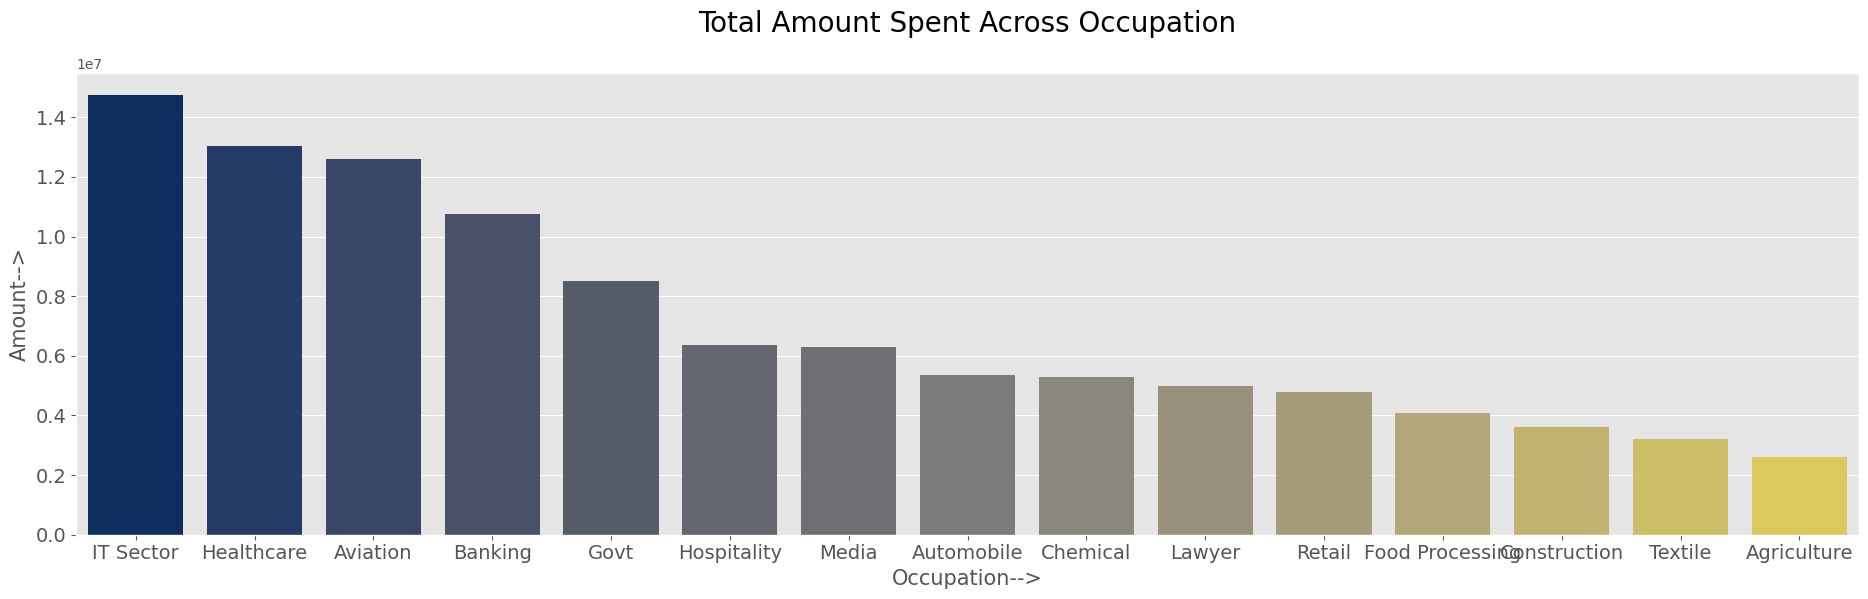

In [ ]:
plt.figure(figsize=(23,6))
sales_state=df.groupby(["Occupation"],as_index=False)["Amount"].sum().sort_values(by="Amount",ascending=False)
gr4=sns.barplot(x="Occupation",y="Amount",data=sales_state,hue="Occupation",palette="cividis")
plt.title("Total Amount Spent Across Occupation\n",size=20)
plt.xlabel("Occupation-->",size=15)
plt.ylabel("Amount-->",size=15)
plt.xticks(size=14)
plt.yticks(size=14)
plt.show()

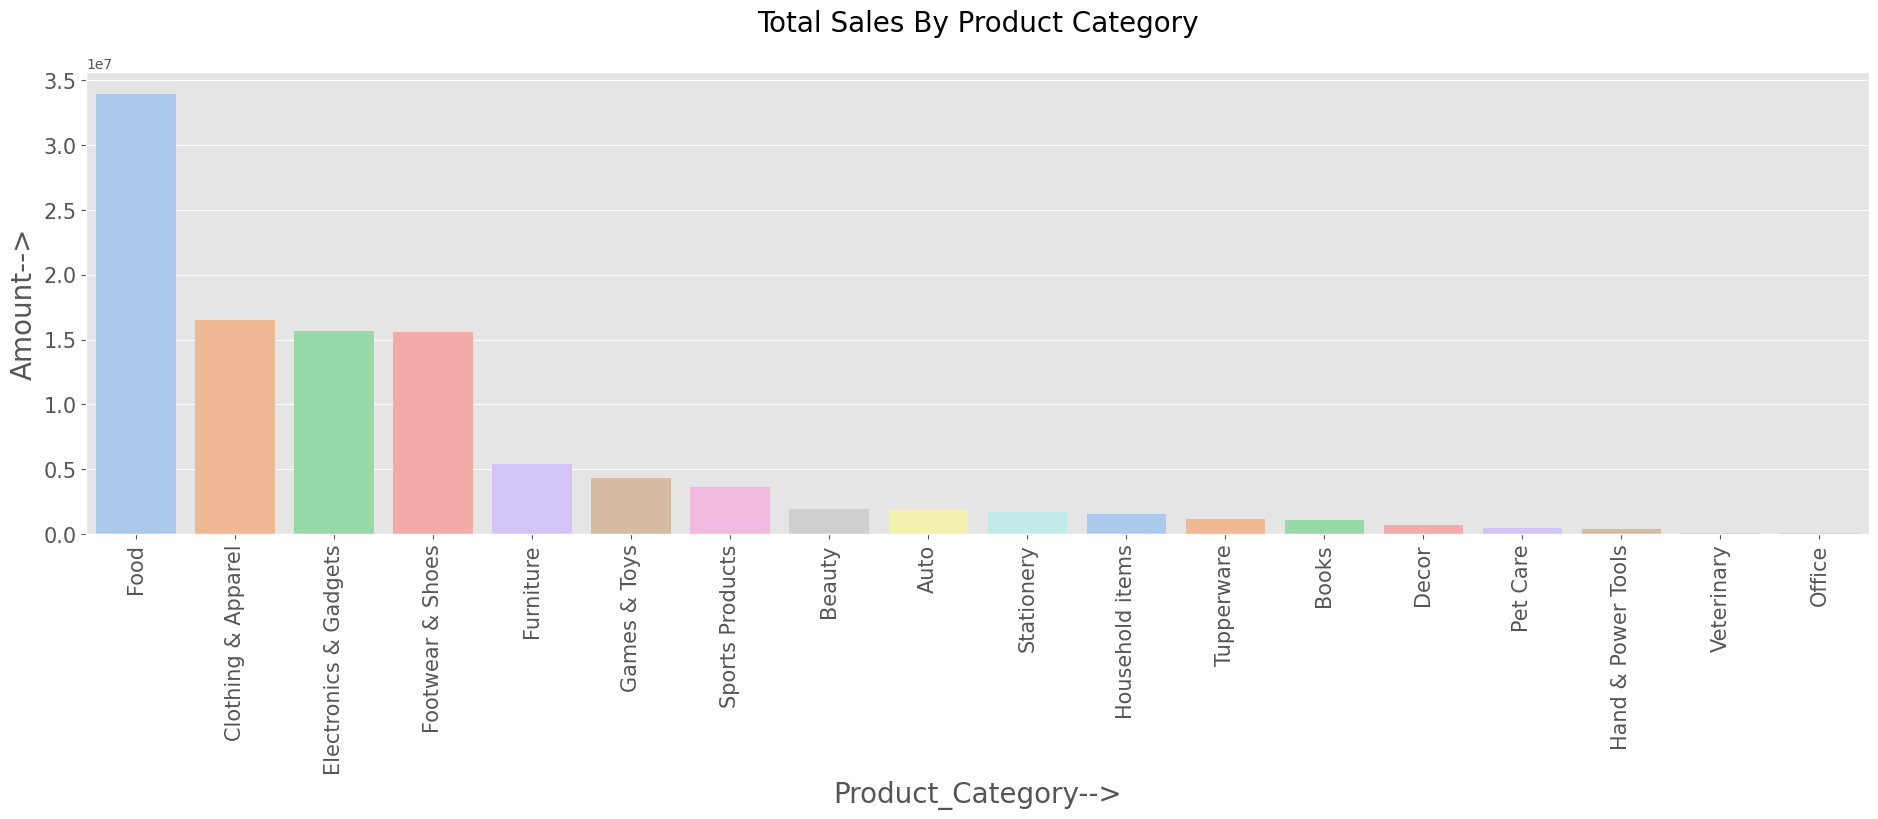

In [ ]:
plt.figure(figsize=(23,6))
sales_state=df.groupby(["Product_Category"],as_index=False)["Amount"].sum().sort_values(by="Amount",ascending=False)
gr4=sns.barplot(x="Product_Category",y="Amount",data=sales_state,hue="Product_Category",palette="pastel")
plt.title("Total Sales By Product Category\n",size=20)
plt.xlabel("Product_Category-->",size=20)
plt.ylabel("Amount-->",size=20)
plt.xticks(size=15,rotation=90)
plt.yticks(size=15)
plt.show()

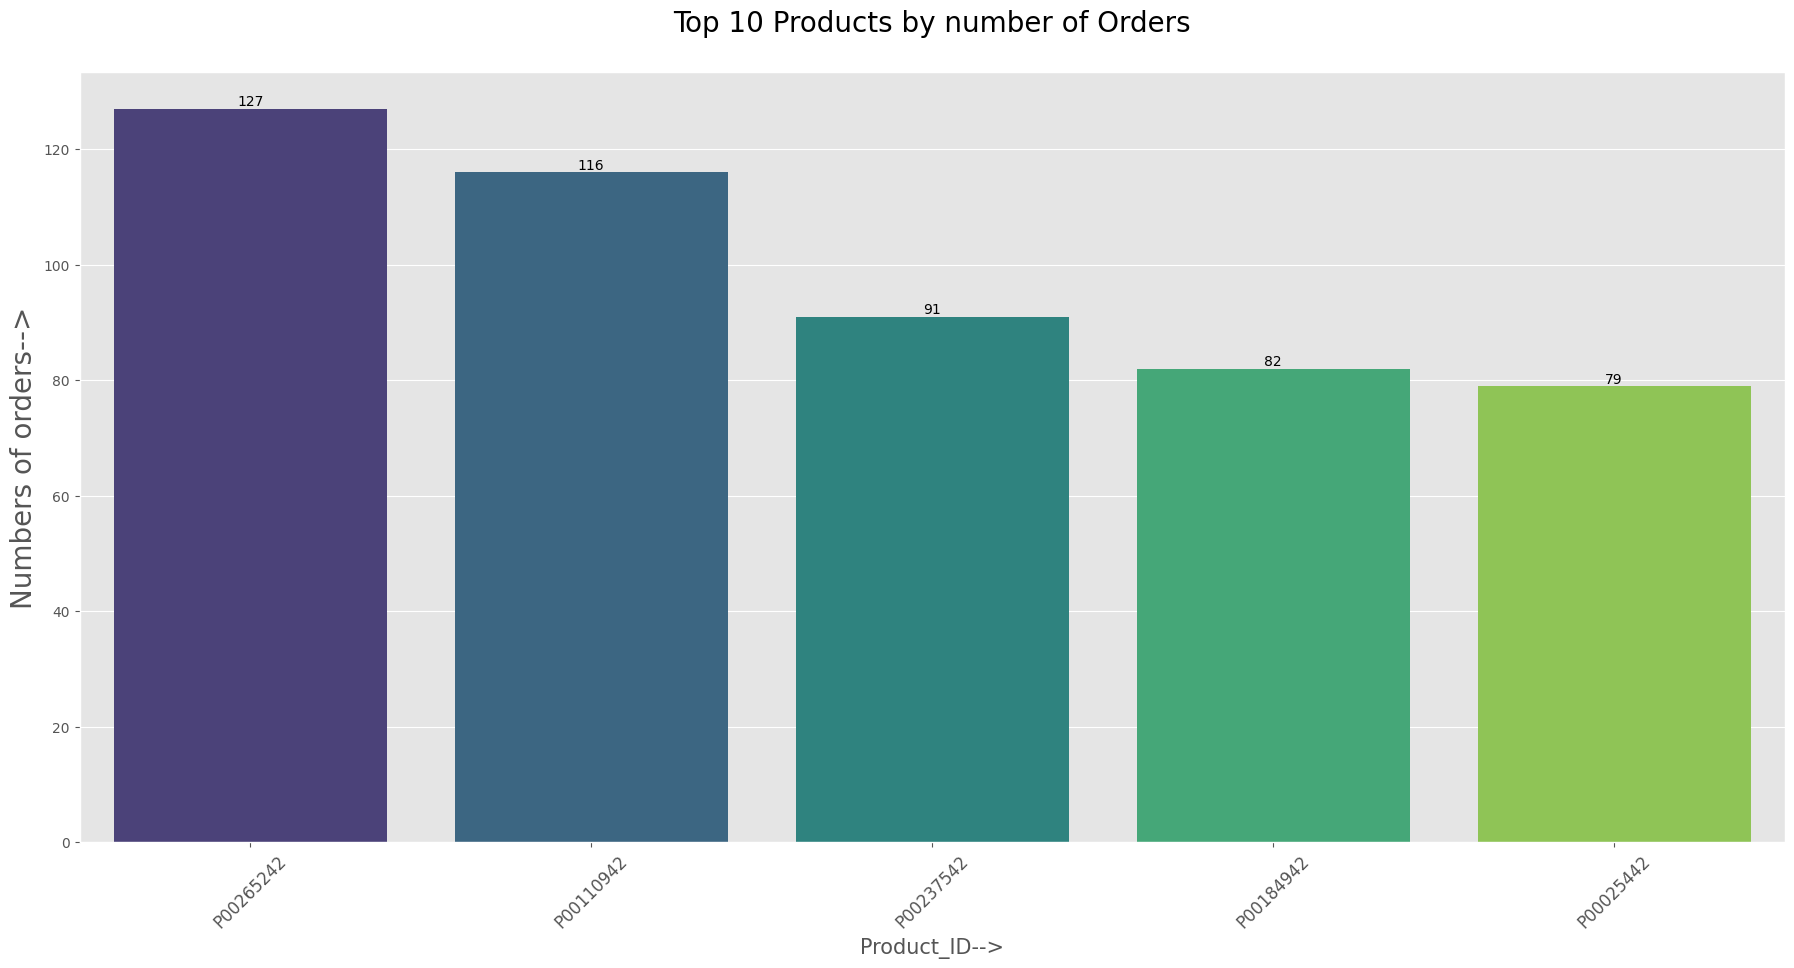

In [ ]:
sales_state=df.groupby(["Product_ID"],as_index=False)["Orders"].sum().sort_values(by="Orders",ascending=False).head()
plt.figure(figsize=(22,10))
ax=sns.barplot(x="Product_ID",y="Orders",data=sales_state,hue="Product_ID",palette="viridis")
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Top 10 Products by number of Orders\n",size=20)
plt.xlabel("Product_ID-->",size=15)
plt.ylabel("Numbers of orders-->",size=20)
plt.xticks(size=12,rotation=45)
plt.yticks(size=10)
plt.show()